In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler
import joblib

🔗 Download (UCI):
https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data

This contains 30 numeric features from scans of cell nuclei, and you must classify tumors as benign or malignant.

In [3]:
from google.colab import files
uploaded = files.upload()

Saving wdbc.data to wdbc.data


In [4]:
cols = ["ID", "Diagnosis", "radius1", "texture1", "perimeter1", "area1", "smoothness1", "compactness1", "concavity1", "concave_points1", "symmetry1", "fractal_dimension1", "radius2", "texture2", "perimeter2", "area2", "smoothness2", "compactness2", "concavity2", "concave_points2", "symmetry2", "fractal_dimension2", "radius3", "texture3", "perimeter3", "area3", "smoothness3", "compactness3", "concavity3", "concave_points3", "symmetry3", "fractal_dimension3",]
df = pd.read_csv("wdbc.data", names=cols)
df.head()

,ID,Diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
#Drop ID column
df = df.drop('ID', axis=1)

# Encode diagnosis (M=1, B=0)
le = LabelEncoder()
df['Diagnosis'] = le.fit_transform(df['Diagnosis'])

# Check
print(df['Diagnosis'].value_counts())

Diagnosis
0    357
1    212
Name: count, dtype: int64


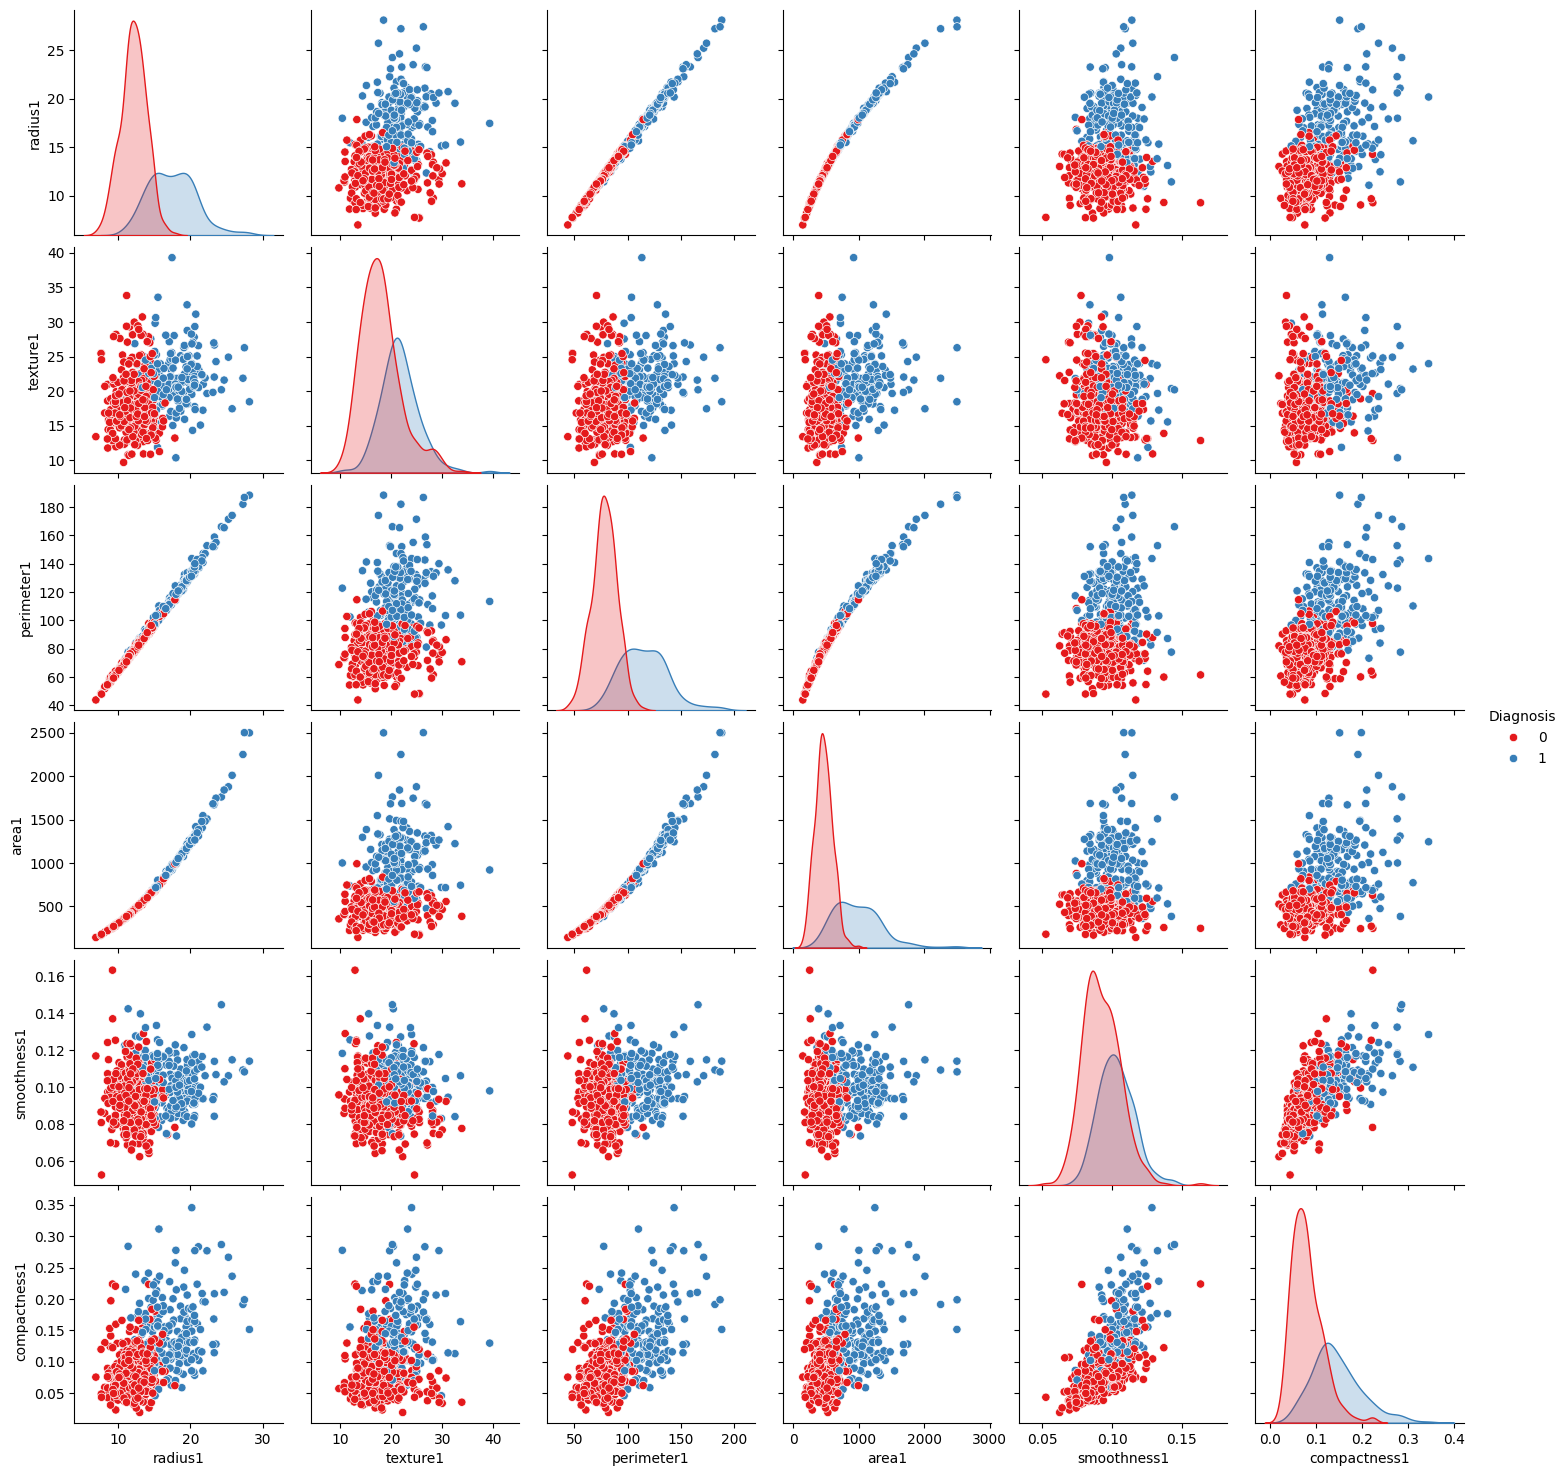

In [6]:
features_to_plot = df.columns[1:7]  # skip Diagnosis column

sns.pairplot(df[features_to_plot].join(df['Diagnosis']), hue='Diagnosis', diag_kind='kde', palette='Set1')
plt.show()

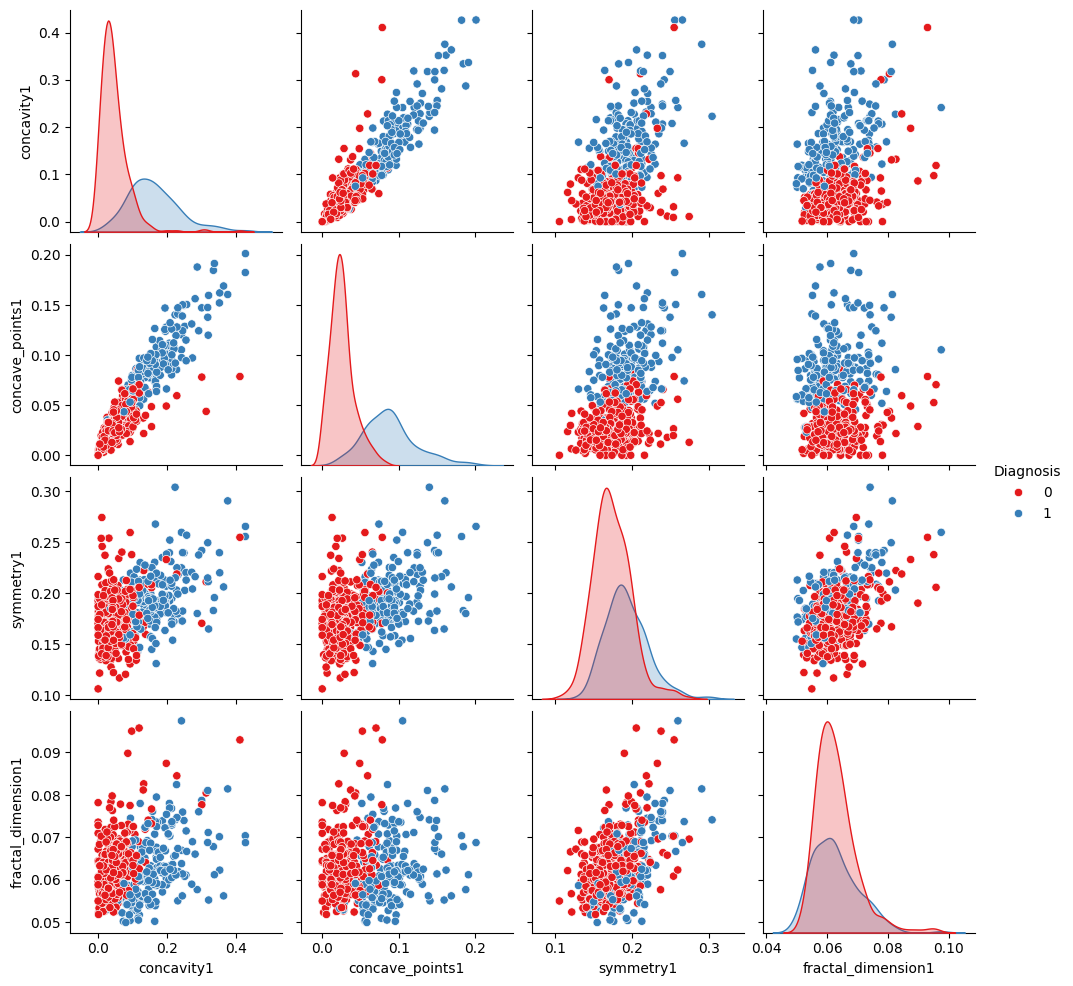

In [7]:
features_to_plot = df.columns[7:11]

sns.pairplot(df[features_to_plot].join(df['Diagnosis']), hue='Diagnosis', diag_kind='kde', palette='Set1')
plt.show()

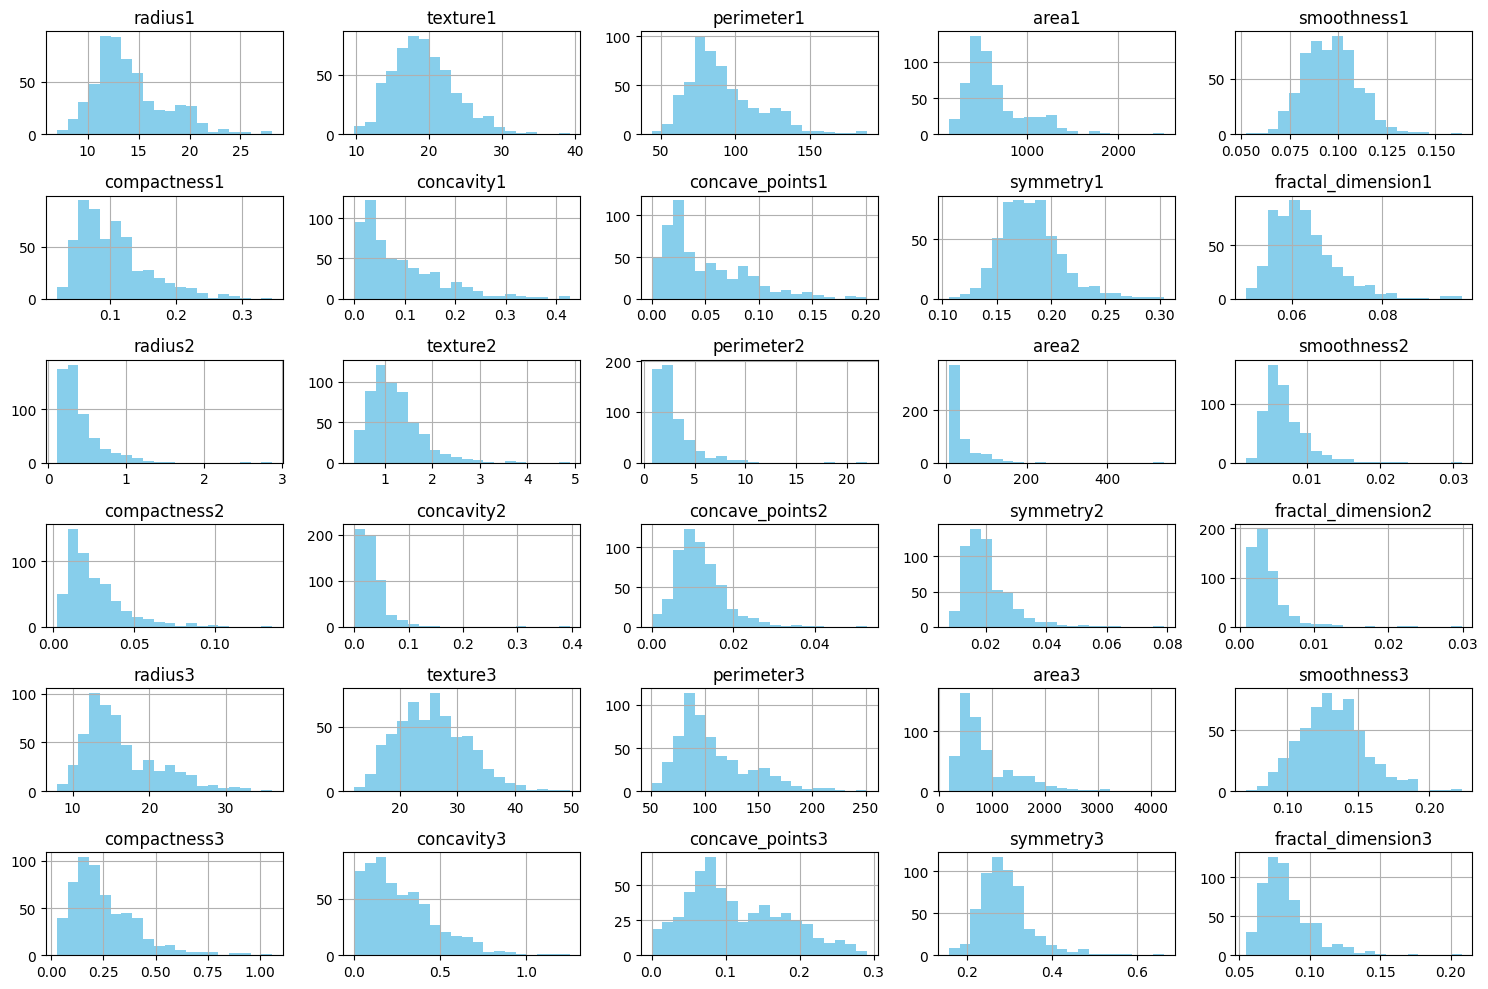

In [8]:
df.iloc[:, 1:].hist(figsize=(15,10), bins=20, color='skyblue')
plt.tight_layout()
plt.show()

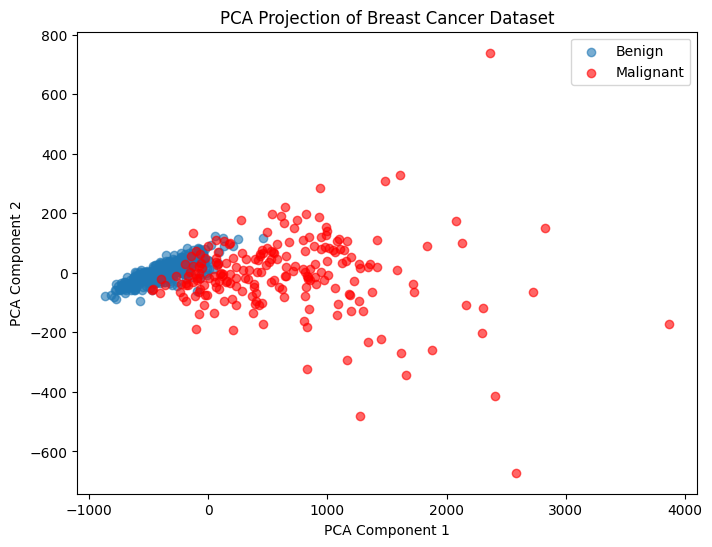

In [32]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df.iloc[:, 1:].values)  # all features
y_labels = df['Diagnosis'].values

plt.figure(figsize=(8,6))
plt.scatter(X_pca[y_labels==0, 0], X_pca[y_labels==0, 1], label='Benign', alpha=0.6)
plt.scatter(X_pca[y_labels==1, 0], X_pca[y_labels==1, 1], label='Malignant', alpha=0.6, color='red')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA Projection of Breast Cancer Dataset')
plt.legend()
plt.show()

In [75]:
# Shuffle dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Split indices
train_end = int(0.7 * len(df))
valid_end = int(0.85 * len(df))

# Split
train = df[:train_end]
valid = df[train_end:valid_end]
test  = df[valid_end:]

# Extract X and y
X_train = train.iloc[:, 1:].values
y_train = train.iloc[:, 0].values

X_valid = valid.iloc[:, 1:].values
y_valid = valid.iloc[:, 0].values

X_test = test.iloc[:, 1:].values
y_test = test.iloc[:, 0].values


# Oversample only training set
ros = RandomOverSampler(random_state=42)
X_train, y_train = ros.fit_resample(X_train, y_train)

print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)

(520, 30) (520,)
(85, 30) (85,)
(86, 30) (86,)


In [76]:
# Convert to 1D NumPy array
y_train = np.ravel(y_train)  # flattens any shape like (n,1) → (n,)

In [77]:
# Count 0s and 1s
(unique, counts) = np.unique(y_train, return_counts=True)
print("Training class distribution:", dict(zip(unique, counts)))

Training class distribution: {np.int64(0): np.int64(260), np.int64(1): np.int64(260)}


In [78]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
X_valid = scaler.transform(X_valid)

In [79]:
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7)

In [80]:
y_pred = knn_model.predict(X_test)

In [81]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.89      0.94        46
           1       0.89      1.00      0.94        40

    accuracy                           0.94        86
   macro avg       0.94      0.95      0.94        86
weighted avg       0.95      0.94      0.94        86



In [82]:

# Train Final KNN
from sklearn.neighbors import KNeighborsClassifier

knn_final = KNeighborsClassifier(n_neighbors= 7, weights='distance')

# Fit the model on the training set
knn_final.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7, weights='distance')

In [83]:
y_test_pred = knn_final.predict(X_test)

In [84]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       1.00      0.89      0.94        46
           1       0.89      1.00      0.94        40

    accuracy                           0.94        86
   macro avg       0.94      0.95      0.94        86
weighted avg       0.95      0.94      0.94        86



In [87]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_valid_pred = knn_final.predict(X_valid)

print("Validation Accuracy:", accuracy_score(y_valid, y_valid_pred))
print(classification_report(y_valid, y_valid_pred))
print(confusion_matrix(y_valid, y_valid_pred))

Validation Accuracy: 0.9294117647058824
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        51
           1       1.00      0.82      0.90        34

    accuracy                           0.93        85
   macro avg       0.95      0.91      0.92        85
weighted avg       0.94      0.93      0.93        85

[[51  0]
 [ 6 28]]


In [88]:
joblib.dump(knn_final, "knn_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [89]:
from google.colab import files
files.download("knn_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>